---
title: "Lecture 22: Dimension reduction"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture22_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

## Rayleigh quotient

For a matrix $\mathbf{A}$ and compatible vector $\mathbf{x}$, $\mathbf{x}^* \mathbf{A} \mathbf{x}$ is scalar-valued.  This type of function is called a **quadratic form**.

. . . 

::: {.callout-note icon=false}
## Definition: Rayleigh quotient
Given symmetric (Hermitian) $\mathbf{A}$ and nonzero vector $\mathbf{x}$, the **Rayleigh quotient** is the function

$$R_{\mathbf{A}}(\mathbf{x}) = \frac{ \mathbf{x}^* \mathbf{A} \mathbf{x}}{\mathbf{x}^* \mathbf{x}}.$$
:::

. . .

If $\mathbf{v}$ is an eigenvector such that $\mathbf{A} \mathbf{v}=\lambda \mathbf{v}$, then one easily calculates that $R_{\mathbf{A}}(\mathbf{v})=\lambda.$ That is, the Rayleigh quotient maps an eigenvector into its associated eigenvalue.

. . .

If $\mathbf{A}^*=\mathbf{A}$, then the Rayleigh quotient has another interesting property: $\nabla R_{\mathbf{A}}(\mathbf{v})=\boldsymbol{0}$ if $\mathbf{v}$ is an eigenvector. By a multidimensional Taylor series, then,

$$R_{\mathbf{A}}(\mathbf{v}+\epsilon\mathbf{z}) = R_{\mathbf{A}}(\mathbf{v}) + 0 + O( \epsilon^2) =  \lambda + O( \epsilon^2),$$

as $\epsilon\to 0$. 

. . .

A good estimate of an eigenvector becomes an even better estimate of an eigenvalue!

---

In [16]:
# | echo: false
using LinearAlgebra
using PrettyTables
using Plots
using Images
using JLD2

In [3]:
n = 20;
λ = 1:n 
D = diagm(λ)
V,_ = qr(randn(n,n))   # get a random orthogonal V
A = V*D*V';

In [4]:
R = x -> (x'*A*x)/(x'*x);  # define RQ

In [5]:
R(V[:,7])   # evaluating the RQ at an evector gives corresponding evalue

7.000000000000001

. . .

In [6]:
# RQ is within O(del^2) of the evalue, given a del perturbation to the evector
δ = @. 1 ./10^(1:5)
eval_diff = zeros(size(δ))
for (k,delta) in enumerate(δ)
    e = randn(n);  e = delta*e/norm(e);
    x = V[:,7] + e
    eval_diff[k] = R(x) - 7
end
labels = ["perturbation δ","δ²","R(x) - λ"]
pretty_table([δ δ.^2 eval_diff], header=labels)

┌────────────────┬─────────┬─────────────┐
│ perturbation δ │      δ² │    R(x) - λ │
├────────────────┼─────────┼─────────────┤
│            0.1 │    0.01 │   0.0275755 │
│           0.01 │  0.0001 │  0.00036161 │
│          0.001 │  1.0e-6 │  6.99687e-6 │
│         0.0001 │  1.0e-8 │  3.39643e-8 │
│         1.0e-5 │ 1.0e-10 │ 2.85269e-10 │
└────────────────┴─────────┴─────────────┘


## Definiteness

In the real case, we called a symmetric matrix $\mathbf{A}$ *symmetric positive definite* (SPD) if $\mathbf{x}^\top \mathbf{A}\mathbf{x} > 0$ for all nonzero vectors $\mathbf{x}$. 

. . .

::: {.callout-warning icon=false}
## Theorem: 
If $\mathbf{A}^\top=\mathbf{A}$, then the following statements are equivalent.

1. $\mathbf{A}$ is SPD.
2. The eigenvalues of $\mathbf{A}$ are positive numbers.
:::


<details><summary>Proof:</summary> 
Suppose item 1 is true. If $\mathbf{A}\mathbf{x} = \lambda \mathbf{x}$ is an eigenpair, then a Rayleigh quotient implies that $\mathbf{x}^\top \mathbf{A}\mathbf{x} = \lambda \mathbf{x}^\top \mathbf{x} = \lambda \|\mathbf{x}\|^2$ and thus, $\lambda > 0$.  Hence item 2 is true. 

Conversely, suppose item 2 is known. Then we can write the EVD as $\mathbf{A}=\mathbf{V}\mathbf{S}^2\mathbf{V}^*$, where the $S_{ii}$ are positive square roots of the eigenvalues. Hence

$$
\mathbf{x}^*\mathbf{A}\mathbf{x} = \mathbf{x}^*\mathbf{V}\mathbf{S}^2\mathbf{V}^*\mathbf{x} = \|\mathbf{S}\mathbf{V}^*\mathbf{x}\|^2 > 0,
$$

as both $\mathbf{S}$ and $\mathbf{V}$ are invertible. Thus, item 1 is true.
</details>

. . .

For a SPD matrix, the EVD $\mathbf{A}=\mathbf{V}\mathbf{D}\mathbf{V}^*$ meets all the requirements of the SVD, provided the ordering of eigenvalues is chosen appropriately. They coincide!

. . .

A symmetric matrix with all negative eigenvalues is called **negative definite**, and one with eigenvalues of different signs is **indefinite**. Finally, if one or more eigenvalues is zero and the rest have one sign, it is positive or negative **semidefinite**.

# Dimension reduction

The SVD provides an optimal rank-constrained approximation to a given matrix -- this proves very useful in a variety of applications.

## SVD Optimality

Let $\mathbf{A}$ be a real $m\times n$ matrix with SVD $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^T$ and (momentarily) $m\ge n$. Another way of writing the thin form of the SVD is

$$\begin{split}
  \mathbf{A} = \hat{\mathbf{U}}\hat{\mathbf{S}}\mathbf{V}^T &=
  \begin{bmatrix}
    \rule[-0.3em]{0pt}{1em} \mathbf{u}_1 & \mathbf{u}_2 & \cdots & \mathbf{u}_n
  \end{bmatrix} \:
  \begin{bmatrix}
    \sigma_1 & & \\
    & \ddots & \\
    & & \sigma_n
  \end{bmatrix} \: 
        \begin{bmatrix}
          \mathbf{v}_1^T \\ \vdots \\ \mathbf{v}_n^T
        \end{bmatrix}\ \\
  &=
  \begin{bmatrix}
    \rule[-0.3em]{0pt}{1em} \sigma_1\mathbf{u}_1  & \cdots & \sigma_n\mathbf{u}_n
  \end{bmatrix}\:
  \begin{bmatrix}
    \mathbf{v}_1^T \\ \vdots \\ \mathbf{v}_n^T
  \end{bmatrix} \\
  &= \sigma_1 \mathbf{u}_{1}\mathbf{v}_{1}^T + \cdots + \sigma_r \mathbf{u}_{r}\mathbf{v}_{r}^T = \sum_{i=1}^r \sigma_i \mathbf{u}_{i}\mathbf{v}_{i}^T,
\end{split}$$

where $r$ is the rank of $\mathbf{A}$. The final formula also holds for the case $m<n$.

---

Each outer product $\mathbf{u}_{i}\mathbf{v}_{i}^T$ is a rank-1 matrix of unit 2-norm. Thanks to the ordering of singular values, this expresses $\mathbf{A}$ as a sum of decreasingly important contributions. 

. . .

This motivates the definition, for $1\le k \le r$,

$$\mathbf{A}_k = \sum_{i=1}^k \sigma_i \mathbf{u}_{i}\mathbf{v}_{i}^T = \mathbf{U}_k \mathbf{S}_k \mathbf{V}_k^T,$$

where $\mathbf{U}_k$ and $\mathbf{V}_k$ are the first $k$ columns of $\mathbf{U}$ and $\mathbf{V}$, respectively, and $\mathbf{S}_k$ is the upper-left $k\times k$ submatrix of $\mathbf{S}$.

. . .

The rank of a sum of matrices is always less than or equal to the sum of the ranks, so $\mathbf{A}_k$ is a rank-$k$ approximation to $\mathbf{A}$. It turns out that $\mathbf{A}_k$ is the *best* rank-$k$ approximation of $\mathbf{A}$, as measured in the matrix 2-norm.

---

::: {.callout-warning icon=false}
## Theorem: 
Suppose $\mathbf{A}$ has rank $r$ and let $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^T$ be an SVD. Let $$\mathbf{A}_k = \sum_{i=1}^k \sigma_i \mathbf{u}_{i}\mathbf{v}_{i}^T = \mathbf{U}_k \mathbf{S}_k \mathbf{V}_k^T$$ for $1\le k < r$. Then

1. $\| \mathbf{A} - \mathbf{A}_k \|_2 = \sigma_{k+1}, \quad k=1,\ldots,r-1$, and
2. If the rank of $\mathbf{B}$ is $k$ or less, then $\| \mathbf{A}-\mathbf{B} \|_2\ge \sigma_{k+1}$.
:::

<details><summary>Proof of part 1:</summary> 
Note that the definition of $\mathbf{A}_k$ is identical to the SVD of $\mathbf{A}$ with $\sigma_{k+1},\ldots,\sigma_r$ all set to zero. This implies that
  
$$\mathbf{A} - \mathbf{A}_k = \mathbf{U}(\mathbf{S}-\hat{\mathbf{S}})\mathbf{V}^T,$$

where $\hat{\mathbf{S}}$ has those same values of $\sigma_i$ replaced by zero. But that makes the above an SVD of $\mathbf{A} - \mathbf{A}_k$, with singular values $0,\ldots,0,\sigma_{k+1},\ldots,\sigma_r$, the largest of which is $\sigma_{k+1}$. That proves the first claim.
</details>

## Compression

If the singular values of $\mathbf{A}$ decrease sufficiently rapidly, then $\mathbf{A}_{k}$ may capture the most significant behavior of the matrix for a reasonably small value of $k$.

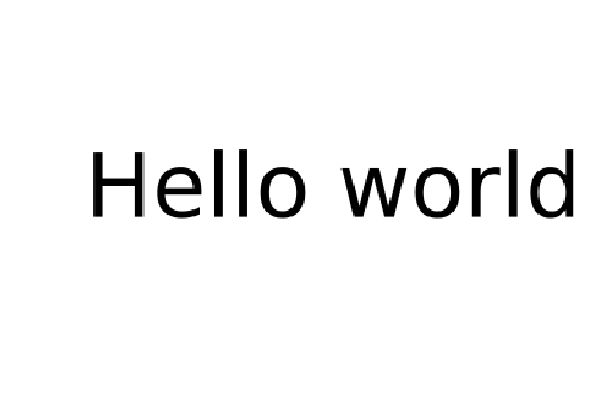

In [10]:
# make an image from text and reload it as matrix
plot(annotations=(0.5,0.5,text("Hello world",44,:center,:center)),
    grid=:none,frame=:none,size=(400,150))
savefig("hello.png")
img = load("hello.png")
A = @. Float64(Gray(img)) 
plot(Gray.(A),frame=:none)

---

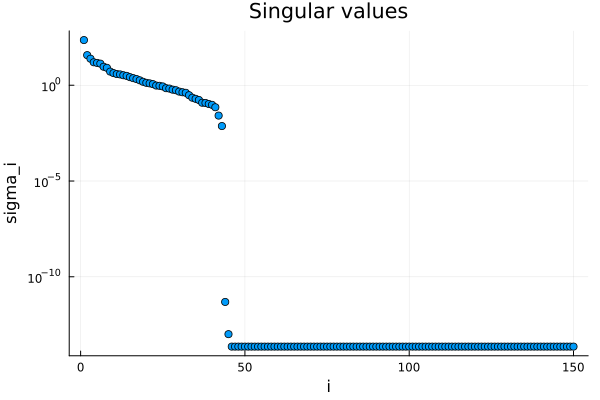

In [8]:
# singular values decrease until they reach numerical zero at k = 45
U,σ,V = svd(A)
scatter(σ,xaxis=("i"), yaxis=(:log10,"sigma_i"),
    title="Singular values",legend=false)

. . .

Rapid decrease suggests that low-rank approximations can be fairly accurate!

---

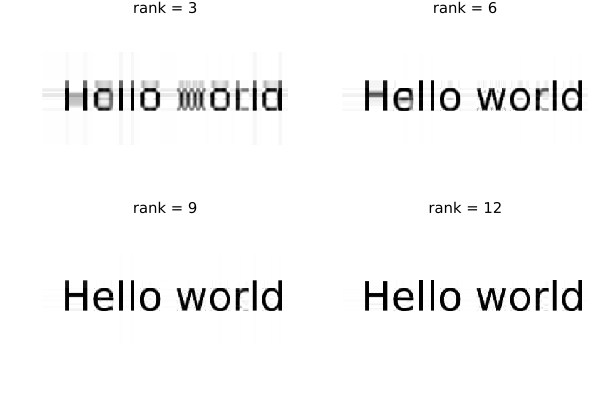

In [11]:
plt = plot(layout=(2,2),frame=:none,aspect_ratio=1,titlefontsize=10)
for i in 1:4
    k = 3i
    Ak = U[:,1:k]*diagm(σ[1:k])*V[:,1:k]'
    plot!(Gray.(Ak),subplot=i,title="rank = $k")
end
plt

In [12]:
m,n = size(A)  # compression ratio for rank-9 approximation
compression = m*n / (9*(m+n+1))

12.099213551119178

## Capturing major trends

The use of dimension reduction offered by low-rank SVD approximation can uncover deep connections and trends that are otherwise obscured by weaker effects and noise.

. . .

One useful way to quantify the decay in the singular values is to compute

$$s_k = \sum_{i=1}^k \sigma_i^2, \quad \tau_k = \frac{s_k}{s_r}, \quad k=1,\ldots,r.$$

. . .

Clearly $0\le \tau_k \le 1$ and $\tau_k$ is non-decreasing as a function of $k$. We can think of $\tau_k$ as the fraction of energy (or in statistical terms, variance) contained in the singular values up to and including the $k$th. 

. . .

**Example**: This matrix data describes the votes on bills in the 111th session of the United States Senate. (The data set was obtained from [https://voteview.com].) Each row is one senator, and each column is a vote item.

In [17]:
@load "voting.jld" A;

┌ Warning: This file was not written with JLD2. Some things may not work.
└ @ JLD2 ~/.julia/packages/JLD2/wLPAN/src/JLD2.jl:288


---

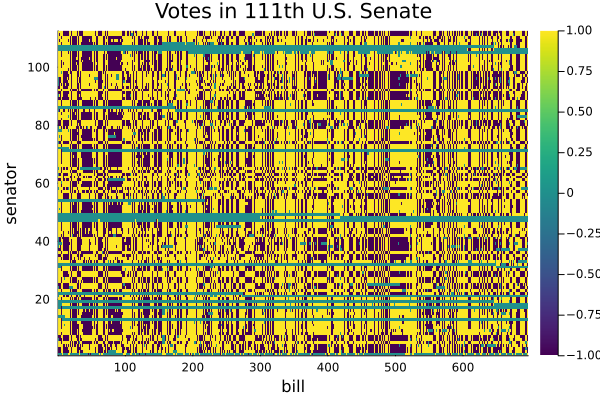

In [19]:
heatmap(A,color=:viridis,
    title="Votes in 111th U.S. Senate",xlabel="bill",ylabel="senator")
    # yellow is yea, blue is nay

---

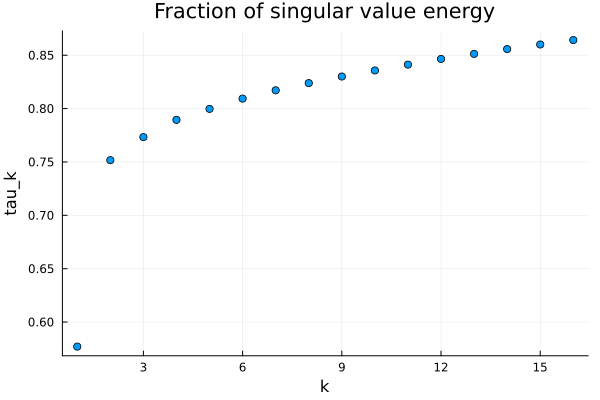

In [ ]:
U,σ,V = svd(A)
τ = cumsum(σ.^2) / sum(σ.^2)
scatter(τ[1:16], xaxis=("k"), yaxis=("tau_k"), 
    title="Fraction of singular value energy",legend=false)
# first and second singular triples (2 vectors and 1 value) 
# contain 58% and 17% of the energy in this dataset

---

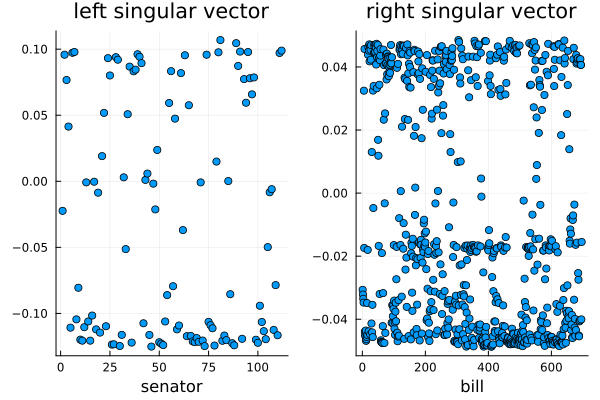

In [24]:
scatter( U[:,1],label="",layout=(1,2),
    xlabel="senator" ,title="left singular vector")
scatter!( V[:,1],label="",subplot=2,
    xlabel="bill",title="right singular vector")
# roughly speaking these vectors indicate how partisan a bill or senator is

---

┌ Warning: This file was not written with JLD2. Some things may not work.
└ @ JLD2 ~/.julia/packages/JLD2/wLPAN/src/JLD2.jl:288


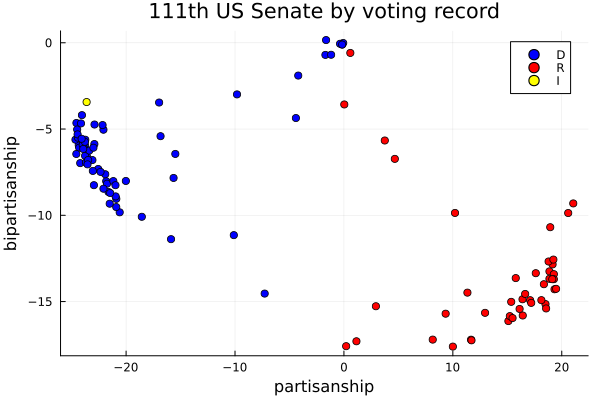

In [26]:
x1 = A*V[:,1];   x2 = A*V[:,2];

@load "voting.jld" Rep Dem Ind
Rep = vec(Rep); Dem = vec(Dem);  Ind = vec(Ind);
scatter(x1[Dem],x2[Dem],color=:blue,label="D",
    xaxis=("partisanship"),yaxis=("bipartisanship"),title="111th US Senate by voting record" )
scatter!(x1[Rep],x2[Rep],color=:red,label="R")
scatter!(x1[Ind],x2[Ind],color=:yellow,label="I")

Projecting the senators' vectors into the first two $\mathbf{V}$-coordinates gives a particularly nice way to reduce them to two dimensions. Political scientists label these dimensions *partisanship* and *bipartisanship*. Here we color them by actual party affiliation (also given in the data file): red for Republican, blue for Democrat, and yellow for independent.

---

Not all data sets can be reduced effectively to a small number of dimensions, but as this demo illustrates, in some cases dimension reduction reveals information that corresponds to real-world understanding.

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->